# <div style="color:#fff;display:fill;border-radius:10px;background-color:#004F98;text-align:center;letter-spacing:0.1px;overflow:hidden;padding:20px;color:white;overflow:hidden;margin:0;font-size:100%">📊 Bike Sales in Europe Analysis</div>

## 🗂️ Table of Contents

1. [Project Overview](#project-overview)
2. [Import Libraries](#import-libraries)
3. [Load Dataset](#load-dataset)
4. [Dataset Shape & Initial Exploration](#initial-exploration)
5. [Data Cleaning & Preprocessing](#data-cleaning)
6. [Sales Analysis](#sales-analysis)
7. [Customer Analysis](#customer-analysis)
8. [Geographic Analysis](#geographic-analysis)
9. [Time Series Analysis](#time-series-analysis)
10. [Discount Analysis](#discount-analysis)
11. [Key Findings & Recommendations](#key-findings)


## 📋 Project Overview

**Objective:** Analyze bike sales data for three European markets — **Germany**, **France**, and the **United Kingdom** — to uncover revenue trends, customer demographics, product performance, and the impact of discounting on profitability.

**Dataset:** Global bike sales CSV (18 columns); filtered to European countries for this analysis.

**Key Questions:**
1. What are the total sales and profit margins?
2. Which products, categories, and regions drive the most revenue?
3. Who are the core customers (age group, gender)?
4. How do sales trends look over time (year / month)?
5. What is the effect of discounting on profit?



## 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## 📂 Load Dataset

In [2]:
data = pd.read_csv("sales.csv")
df = data.copy()
df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


## 📐 Dataset Shape

In [3]:
print(f" 📊 Data Shape:{df.shape}")

 📊 Data Shape:(113036, 18)


In [4]:
print(f'📊 Number of rows: {df.shape[0]}')
print(f'📊 Number of columns: {df.shape[1]}')

📊 Number of rows: 113036
📊 Number of columns: 18


## 🔍 Initial Data Exploration

In [5]:
print('📌 First 10 rows of the dataset:')
df.head(10)

📌 First 10 rows of the dataset:


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418
5,2016-05-15,15,May,2016,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,5,45,120,297,225,522
6,2014-05-22,22,May,2014,47,Adults (35-64),F,Australia,Victoria,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,199,180,379
7,2016-05-22,22,May,2016,47,Adults (35-64),F,Australia,Victoria,Accessories,Bike Racks,Hitch Rack - 4-Bike,2,45,120,100,90,190
8,2014-02-22,22,February,2014,35,Adults (35-64),M,Australia,Victoria,Accessories,Bike Racks,Hitch Rack - 4-Bike,22,45,120,1096,990,2086
9,2016-02-22,22,February,2016,35,Adults (35-64),M,Australia,Victoria,Accessories,Bike Racks,Hitch Rack - 4-Bike,21,45,120,1046,945,1991


In [6]:
print('📌 Last 5 rows of the dataset:')
df.tail()

📌 Last 5 rows of the dataset:


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260
113035,2016-03-04,4,March,2016,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",23,24,64,655,552,1207


In [7]:
print('📋 Dataset Information:')
df.info()

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  Sub_Category      113036 non-null  object
 11  Product           113036 non-null  object
 12  Order_Quantity    113036 non-null  int64 
 13  Unit_Cost         113036 non-null  int64 
 14  Unit_Price        113036 non-null  int64 
 15  Profit            113036 non-null  int64 
 16  Cost           

In [8]:
print('🔢 Data Types:')
print(df.dtypes)

🔢 Data Types:
Date                object
Day                  int64
Month               object
Year                 int64
Customer_Age         int64
Age_Group           object
Customer_Gender     object
Country             object
State               object
Product_Category    object
Sub_Category        object
Product             object
Order_Quantity       int64
Unit_Cost            int64
Unit_Price           int64
Profit               int64
Cost                 int64
Revenue              int64
dtype: object


In [9]:
print('📝 Column Names:')
print(df.columns.tolist())

📝 Column Names:
['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category', 'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue']


In [10]:
print('📊 Descriptive Statistics (Numerical):')
df.describe()

📊 Descriptive Statistics (Numerical):


,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
count,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000
mean,15.665753,2014.401739,35.919212,11.901660,267.296366,452.938427,285.051665,469.318695,754.370360
std,8.781567,1.272510,11.021936,9.561857,549.835483,922.071219,453.887443,884.866118,1309.094674
min,1.000000,2011.000000,17.000000,1.000000,1.000000,2.000000,-30.000000,1.000000,2.000000
25%,8.000000,2013.000000,28.000000,2.000000,2.000000,5.000000,29.000000,28.000000,63.000000
50%,16.000000,2014.000000,35.000000,10.000000,9.000000,24.000000,101.000000,108.000000,223.000000
75%,23.000000,2016.000000,43.000000,20.000000,42.000000,70.000000,358.000000,432.000000,800.000000
max,31.000000,2016.000000,87.000000,32.000000,2171.000000,3578.000000,15096.000000,42978.000000,58074.000000


In [11]:
print('📊 Descriptive Statistics (Categorical):')
df.describe(include='object')

📊 Descriptive Statistics (Categorical):


,Date,Month,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product
count,113036,113036,113036,113036,113036,113036,113036,113036,113036
unique,1884,12,4,2,6,53,3,17,130
top,2016-03-01,June,Adults (35-64),M,United States,California,Accessories,Tires and Tubes,Water Bottle - 30 oz.
freq,288,11234,55824,58312,39206,22450,70120,33870,10794


In [12]:
df["Age_Group"].unique()

array(['Youth (<25)', 'Adults (35-64)', 'Young Adults (25-34)',
       'Seniors (64+)'], dtype=object)

In [13]:
df["Country"].unique()

array(['Canada', 'Australia', 'United States', 'Germany', 'France',
       'United Kingdom'], dtype=object)

⚠️ The dataset is not limited to Europe; it includes global markets such as Canada, Australia, and the United States.
Therefore, a filtering step will be applied to focus on European countries only.

In [14]:
df["State"].unique()

array(['British Columbia', 'New South Wales', 'Victoria', 'Oregon',
       'California', 'Saarland', 'Seine Saint Denis', 'Moselle',
       'Queensland', 'England', 'Nord', 'Washington', 'Hessen',
       'Nordrhein-Westfalen', 'Hamburg', 'Loir et Cher', 'Kentucky',
       'Seine (Paris)', 'South Australia', 'Loiret', 'Alberta', 'Bayern',
       'Hauts de Seine', 'Yveline', 'Essonne', "Val d'Oise", 'Tasmania',
       'Seine et Marne', 'Val de Marne', 'Pas de Calais',
       'Charente-Maritime', 'Garonne (Haute)', 'Brandenburg', 'Texas',
       'New York', 'Florida', 'Somme', 'Illinois', 'South Carolina',
       'North Carolina', 'Georgia', 'Virginia', 'Ohio', 'Ontario',
       'Wyoming', 'Missouri', 'Montana', 'Utah', 'Minnesota',
       'Mississippi', 'Massachusetts', 'Arizona', 'Alabama'], dtype=object)

In [15]:
df["Product_Category"].unique()

array(['Accessories', 'Clothing', 'Bikes'], dtype=object)

In [16]:
df["Sub_Category"].unique()

array(['Bike Racks', 'Bike Stands', 'Bottles and Cages', 'Caps',
       'Cleaners', 'Fenders', 'Gloves', 'Helmets', 'Hydration Packs',
       'Jerseys', 'Mountain Bikes', 'Road Bikes', 'Shorts', 'Socks',
       'Tires and Tubes', 'Touring Bikes', 'Vests'], dtype=object)

In [17]:
df["Month"].unique()

array(['November', 'March', 'May', 'February', 'July', 'August',
       'September', 'January', 'December', 'June', 'October', 'April'],
      dtype=object)

In [18]:
df["Product"].unique()

array(['Hitch Rack - 4-Bike', 'All-Purpose Bike Stand',
       'Mountain Bottle Cage', 'Water Bottle - 30 oz.',
       'Road Bottle Cage', 'AWC Logo Cap', 'Bike Wash - Dissolver',
       'Fender Set - Mountain', 'Half-Finger Gloves, L',
       'Half-Finger Gloves, M', 'Half-Finger Gloves, S',
       'Sport-100 Helmet, Black', 'Sport-100 Helmet, Red',
       'Sport-100 Helmet, Blue', 'Hydration Pack - 70 oz.',
       'Short-Sleeve Classic Jersey, XL',
       'Short-Sleeve Classic Jersey, L', 'Short-Sleeve Classic Jersey, M',
       'Short-Sleeve Classic Jersey, S', 'Long-Sleeve Logo Jersey, M',
       'Long-Sleeve Logo Jersey, XL', 'Long-Sleeve Logo Jersey, L',
       'Long-Sleeve Logo Jersey, S', 'Mountain-100 Silver, 38',
       'Mountain-100 Silver, 44', 'Mountain-100 Black, 48',
       'Mountain-100 Silver, 48', 'Mountain-100 Black, 38',
       'Mountain-200 Silver, 38', 'Mountain-100 Black, 44',
       'Mountain-100 Silver, 42', 'Mountain-200 Black, 46',
       'Mountain-200 Silver

📄 Note:
The product column contains multiple entries for the same product due to variations in size, color, or model. For analysis purposes, these variants can be considered as a single product if their unit cost and unit price are identical across all variants. This will help simplify the dataset and provide a clearer view of sales performance per product.

## 🧹 Data Cleaning & Preprocessing

In [19]:
print('❌ Missing Values in Each Column:')
null_counts = df.isnull().sum()
print(null_counts)

❌ Missing Values in Each Column:
Date                0
Day                 0
Month               0
Year                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Country             0
State               0
Product_Category    0
Sub_Category        0
Product             0
Order_Quantity      0
Unit_Cost           0
Unit_Price          0
Profit              0
Cost                0
Revenue             0
dtype: int64


In [20]:
duplicates_count = df.duplicated().sum()
print(f'🔍 Number of Duplicate Rows: {duplicates_count:}')

🔍 Number of Duplicate Rows: 1000


In [21]:
df[df.duplicated()].head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
1021,2013-12-19,19,December,2013,22,Youth (<25),M,Australia,New South Wales,Accessories,Bike Stands,All-Purpose Bike Stand,9,59,159,714,531,1245
1091,2015-09-30,30,September,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,5,4,10,20,20,40
1093,2013-10-24,24,October,2013,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,2,4,10,8,8,16
1095,2015-10-24,24,October,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,1,4,10,4,4,8
1193,2016-01-15,15,January,2016,42,Adults (35-64),M,France,Seine Saint Denis,Accessories,Bottles and Cages,Water Bottle - 30 oz.,14,2,5,29,28,57


In [22]:
df[df.duplicated(keep=False)]

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
1020,2013-12-19,19,December,2013,22,Youth (<25),M,Australia,New South Wales,Accessories,Bike Stands,All-Purpose Bike Stand,9,59,159,714,531,1245
1021,2013-12-19,19,December,2013,22,Youth (<25),M,Australia,New South Wales,Accessories,Bike Stands,All-Purpose Bike Stand,9,59,159,714,531,1245
1090,2015-09-30,30,September,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,5,4,10,20,20,40
1091,2015-09-30,30,September,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,5,4,10,20,20,40
1092,2013-10-24,24,October,2013,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,2,4,10,8,8,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111265,2014-04-27,27,April,2014,31,Young Adults (25-34),M,United States,Washington,Bikes,Touring Bikes,"Touring-1000 Blue, 50",1,1482,2384,378,1482,1860
111952,2013-09-20,20,September,2013,42,Adults (35-64),M,Canada,British Columbia,Bikes,Touring Bikes,"Touring-3000 Yellow, 44",1,461,742,274,461,735
111953,2013-09-20,20,September,2013,42,Adults (35-64),M,Canada,British Columbia,Bikes,Touring Bikes,"Touring-3000 Yellow, 44",1,461,742,274,461,735
111954,2015-09-20,20,September,2015,42,Adults (35-64),M,Canada,British Columbia,Bikes,Touring Bikes,"Touring-3000 Yellow, 44",1,461,742,274,461,735


In [23]:
df = df.drop_duplicates()

In [24]:
print(f" 📊 Data Shape:{df.shape}")

 📊 Data Shape:(112036, 18)


⚠️Duplicate rows were identified where all feature values were identical. These were considered data entry errors and removed to ensure accurate analysis.

In [25]:
duplicates_count = df.T.duplicated().sum()
print(f'🔍 Number of Duplicate Columns: {duplicates_count:}')

🔍 Number of Duplicate Columns: 0


In [26]:
df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [27]:
print("📌 Filter applied: Europe only 🌍")
europe_countries = ["Germany", "France", "United Kingdom"]
df = df[df["Country"].isin(europe_countries)]

📌 Filter applied: Europe only 🌍


In [28]:
df["Country"].unique()

array(['Germany', 'France', 'United Kingdom'], dtype=object)

In [29]:
print(f" 📊 Data Shape:{df.shape}")

 📊 Data Shape:(35433, 18)


In [30]:
print("Converted Date column to datetime format 🗓️")
df["Date"] = pd.to_datetime(df["Date"])

Converted Date column to datetime format 🗓️


In [31]:
print('🔢 Data Types:')
print(df.dtypes)

🔢 Data Types:
Date                datetime64[ns]
Day                          int64
Month                       object
Year                         int64
Customer_Age                 int64
Age_Group                   object
Customer_Gender             object
Country                     object
State                       object
Product_Category            object
Sub_Category                object
Product                     object
Order_Quantity               int64
Unit_Cost                    int64
Unit_Price                   int64
Profit                       int64
Cost                         int64
Revenue                      int64
dtype: object


In [32]:
print("📌 Verified financial calculations 🧮")
(df["Revenue"] == df["Unit_Price"] * df["Order_Quantity"]).all()

📌 Verified financial calculations 🧮


np.False_

In [33]:
(df["Cost"] == df["Unit_Cost"] * df["Order_Quantity"]).all()

np.True_

In [34]:
(df["Profit"] == df["Revenue"] - df["Cost"]).all()

np.True_

While cost and profit calculations were consistent, revenue did not always match Unit Price × Quantity, indicating that Unit Price represents a base price, while actual revenue reflects discounts or pricing adjustments.

In [35]:
invalid_rows = df[df["Revenue"] != df["Unit_Price"] * df["Order_Quantity"]]
len(invalid_rows)

34421

In [36]:
df["Sales"] = df["Unit_Price"] * df["Order_Quantity"]
df["diff"] = df["Revenue"] - df["Sales"]
df["diff"].describe()

count    35433.000000
mean       -80.532978
std        171.611131
min      -3435.000000
25%        -89.000000
50%        -22.000000
75%         -5.000000
max          0.000000
Name: diff, dtype: float64

In [37]:
df["discount"] = -df["diff"]

📄 Note:

New columns were added to analyze pricing behavior.

expected_revenue represents the calculated value (Unit Price × Quantity).

diff shows the difference from actual revenue.

discount reflects the reduction applied.

Negative differences indicate the presence of discounts in most transactions.

In [38]:
df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,...,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Sales,diff,discount
48,2013-08-07,7,August,2013,38,Adults (35-64),M,Germany,Saarland,Accessories,...,Hitch Rack - 4-Bike,3,45,120,160,135,295,360,-65,65
49,2015-08-07,7,August,2015,38,Adults (35-64),M,Germany,Saarland,Accessories,...,Hitch Rack - 4-Bike,1,45,120,53,45,98,120,-22,22
50,2013-07-15,15,July,2013,52,Adults (35-64),F,France,Seine Saint Denis,Accessories,...,Hitch Rack - 4-Bike,8,45,120,427,360,787,960,-173,173
51,2015-07-15,15,July,2015,52,Adults (35-64),F,France,Seine Saint Denis,Accessories,...,Hitch Rack - 4-Bike,8,45,120,427,360,787,960,-173,173
52,2013-08-17,17,August,2013,43,Adults (35-64),F,France,Moselle,Accessories,...,Hitch Rack - 4-Bike,28,45,120,1697,1260,2957,3360,-403,403


In [39]:
print("🛒✅consolidating product variants (size, color, model) into single products where unit cost and price are identica")
df['Base_Product'] = df['Product'].str.split(',').str[0].str.strip()
grouped = df.groupby('Base_Product')
def check_equal_cost_price(group):
    return group['Unit_Cost'].nunique() == 1 and group['Unit_Price'].nunique() == 1
equal_cost_price = grouped.filter(check_equal_cost_price)   

print(f"number of base products = {df["Base_Product"].nunique()}")
print(df["Base_Product"].unique())

🛒✅consolidating product variants (size, color, model) into single products where unit cost and price are identica
number of base products = 47
['Hitch Rack - 4-Bike' 'All-Purpose Bike Stand' 'Road Bottle Cage'
 'Water Bottle - 30 oz.' 'Mountain Bottle Cage' 'AWC Logo Cap'
 'Bike Wash - Dissolver' 'Fender Set - Mountain' 'Half-Finger Gloves'
 'Sport-100 Helmet' 'Hydration Pack - 70 oz.' 'Long-Sleeve Logo Jersey'
 'Short-Sleeve Classic Jersey' 'Mountain-500 Silver' 'Mountain-100 Silver'
 'Mountain-200 Silver' 'Mountain-100 Black' 'Mountain-200 Black'
 'Mountain-400-W Silver' 'Mountain-500 Black' 'Road-750 Black'
 'Road-350-W Yellow' 'Road-250 Black' 'Road-150 Red' 'Road-550-W Yellow'
 'Road-250 Red' 'Road-650 Black' 'Road-650 Red' "Women's Mountain Shorts"
 'Racing Socks' 'Patch Kit/8 Patches' 'LL Road Tire' 'LL Mountain Tire'
 'Touring Tire Tube' 'Touring Tire' 'HL Mountain Tire' 'Road Tire Tube'
 'ML Mountain Tire' 'HL Road Tire' 'Mountain Tire Tube' 'ML Road Tire'
 'Touring-2000 Blue'

In [40]:
equal_cost_price['Base_Product'].unique()

array(['Hitch Rack - 4-Bike', 'All-Purpose Bike Stand',
       'Road Bottle Cage', 'Water Bottle - 30 oz.',
       'Mountain Bottle Cage', 'AWC Logo Cap', 'Bike Wash - Dissolver',
       'Fender Set - Mountain', 'Half-Finger Gloves', 'Sport-100 Helmet',
       'Hydration Pack - 70 oz.', 'Long-Sleeve Logo Jersey',
       'Short-Sleeve Classic Jersey', 'Mountain-500 Silver',
       'Mountain-100 Silver', 'Mountain-200 Silver', 'Mountain-100 Black',
       'Mountain-200 Black', 'Mountain-400-W Silver',
       'Mountain-500 Black', 'Road-750 Black', 'Road-350-W Yellow',
       'Road-250 Black', 'Road-150 Red', 'Road-550-W Yellow',
       'Road-650 Black', 'Road-650 Red', "Women's Mountain Shorts",
       'Racing Socks', 'Patch Kit/8 Patches', 'LL Road Tire',
       'LL Mountain Tire', 'Touring Tire Tube', 'Touring Tire',
       'HL Mountain Tire', 'Road Tire Tube', 'ML Mountain Tire',
       'HL Road Tire', 'Mountain Tire Tube', 'ML Road Tire',
       'Touring-2000 Blue', 'Touring-1000 Yel

In [41]:
equal_cost_price['Base_Product'].nunique()

46

In [42]:
summary = equal_cost_price.groupby('Base_Product').agg({
    'Order_Quantity': 'sum',   
    'Unit_Cost': 'first',      
    'Unit_Price': 'first',    
    'Revenue': 'sum',          
    'Profit': 'sum'            
}).reset_index()
summary

,Base_Product,Order_Quantity,Unit_Cost,Unit_Price,Revenue,Profit
0,AWC Logo Cap,25849,7,9,212150,31207
1,All-Purpose Bike Stand,692,59,159,99242,58414
2,Bike Wash - Dissolver,5936,3,8,43463,25655
3,Classic Vest,4050,24,64,233935,136735
4,Fender Set - Mountain,12502,8,22,248943,148927
5,HL Mountain Tire,5458,13,35,177242,106288
6,HL Road Tire,5202,12,33,155304,92880
7,Half-Finger Gloves,10234,9,24,222719,130613
8,Hitch Rack - 4-Bike,1297,45,120,140365,82000
9,Hydration Pack - 70 oz.,4726,21,55,237282,138036


In [43]:
different_cost_price = df[~df['Base_Product'].isin(summary['Base_Product'])]
different_cost_price["Product"].unique()

array(['Road-250 Red, 58', 'Road-250 Red, 44', 'Road-250 Red, 52',
       'Road-250 Red, 48'], dtype=object)

In [44]:
def consolidated_name(group):
    if group['Unit_Cost'].nunique() == 1 and group['Unit_Price'].nunique() == 1:
        return group['Base_Product'].iloc[0]  
    else:
        return None 


consolidated_dict = grouped.apply(consolidated_name).to_dict()


df['Consolidated_Product'] = df['Base_Product'].map(consolidated_dict)

df['Consolidated_Product'] = df['Consolidated_Product'].fillna(df['Product'])

C:\Users\My Pc\AppData\Local\Temp\ipykernel_10992\616446952.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  consolidated_dict = grouped.apply(consolidated_name).to_dict()


In [45]:
df = df.drop(columns=['Product'])


df = df.rename(columns={'Consolidated_Product': 'Product'})

In [46]:
df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,...,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Sales,diff,discount,Base_Product,Product
48,2013-08-07,7,August,2013,38,Adults (35-64),M,Germany,Saarland,Accessories,...,45,120,160,135,295,360,-65,65,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike
49,2015-08-07,7,August,2015,38,Adults (35-64),M,Germany,Saarland,Accessories,...,45,120,53,45,98,120,-22,22,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike
50,2013-07-15,15,July,2013,52,Adults (35-64),F,France,Seine Saint Denis,Accessories,...,45,120,427,360,787,960,-173,173,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike
51,2015-07-15,15,July,2015,52,Adults (35-64),F,France,Seine Saint Denis,Accessories,...,45,120,427,360,787,960,-173,173,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike
52,2013-08-17,17,August,2013,43,Adults (35-64),F,France,Moselle,Accessories,...,45,120,1697,1260,2957,3360,-403,403,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike


In [47]:
df['Product'].nunique()

50

In [48]:
df['Product'].unique()

array(['Hitch Rack - 4-Bike', 'All-Purpose Bike Stand',
       'Road Bottle Cage', 'Water Bottle - 30 oz.',
       'Mountain Bottle Cage', 'AWC Logo Cap', 'Bike Wash - Dissolver',
       'Fender Set - Mountain', 'Half-Finger Gloves', 'Sport-100 Helmet',
       'Hydration Pack - 70 oz.', 'Long-Sleeve Logo Jersey',
       'Short-Sleeve Classic Jersey', 'Mountain-500 Silver',
       'Mountain-100 Silver', 'Mountain-200 Silver', 'Mountain-100 Black',
       'Mountain-200 Black', 'Mountain-400-W Silver',
       'Mountain-500 Black', 'Road-750 Black', 'Road-350-W Yellow',
       'Road-250 Black', 'Road-150 Red', 'Road-550-W Yellow',
       'Road-250 Red, 58', 'Road-250 Red, 44', 'Road-250 Red, 52',
       'Road-250 Red, 48', 'Road-650 Black', 'Road-650 Red',
       "Women's Mountain Shorts", 'Racing Socks', 'Patch Kit/8 Patches',
       'LL Road Tire', 'LL Mountain Tire', 'Touring Tire Tube',
       'Touring Tire', 'HL Mountain Tire', 'Road Tire Tube',
       'ML Mountain Tire', 'HL Road Tir

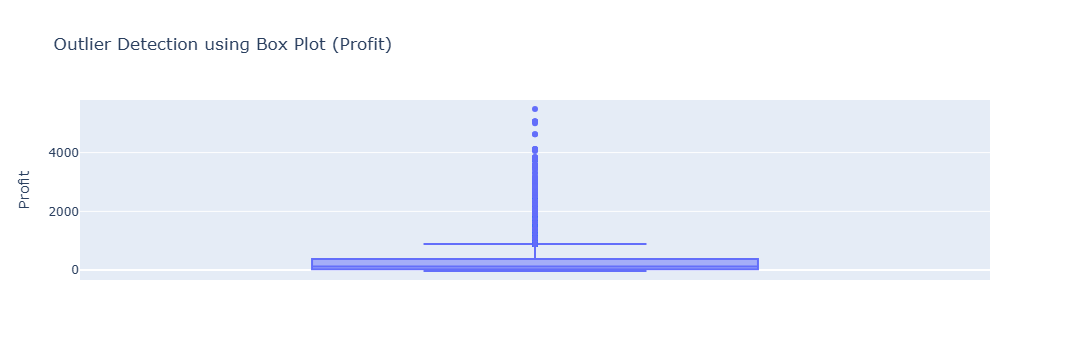

In [49]:
fig = px.box(
    df,
    y="Profit",   
    title="Outlier Detection using Box Plot (Profit)"
)

fig.show()

In [50]:
losses = df[df["Profit"] < 0]

In [51]:
losses

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,...,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Sales,diff,discount,Base_Product,Product
17098,2013-12-09,9,December,2013,20,Youth (<25),M,France,Yveline,Clothing,...,7,9,-3,147,144,189,-45,45,AWC Logo Cap,AWC Logo Cap
17099,2015-12-09,9,December,2015,20,Youth (<25),M,France,Yveline,Clothing,...,7,9,-4,161,157,207,-50,50,AWC Logo Cap,AWC Logo Cap
17484,2013-10-23,23,October,2013,34,Young Adults (25-34),M,France,Yveline,Clothing,...,7,9,-4,196,192,252,-60,60,AWC Logo Cap,AWC Logo Cap
17485,2015-10-23,23,October,2015,34,Young Adults (25-34),M,France,Yveline,Clothing,...,7,9,-5,203,198,261,-63,63,AWC Logo Cap,AWC Logo Cap
17486,2014-03-23,23,March,2014,34,Young Adults (25-34),M,France,Yveline,Clothing,...,7,9,-1,28,27,36,-9,9,AWC Logo Cap,AWC Logo Cap
17662,2013-11-18,18,November,2013,48,Adults (35-64),M,France,Yveline,Clothing,...,7,9,-3,147,144,189,-45,45,AWC Logo Cap,AWC Logo Cap
17663,2015-11-18,18,November,2015,48,Adults (35-64),M,France,Yveline,Clothing,...,7,9,-3,133,130,171,-41,41,AWC Logo Cap,AWC Logo Cap
17972,2013-09-12,12,September,2013,22,Youth (<25),M,France,Yveline,Clothing,...,7,9,-1,28,27,36,-9,9,AWC Logo Cap,AWC Logo Cap
17973,2015-09-12,12,September,2015,22,Youth (<25),M,France,Yveline,Clothing,...,7,9,-1,28,27,36,-9,9,AWC Logo Cap,AWC Logo Cap
18130,2014-07-07,7,July,2014,30,Young Adults (25-34),M,France,Yveline,Clothing,...,7,9,-2,91,89,117,-28,28,AWC Logo Cap,AWC Logo Cap


In [52]:
losses['Product'].unique()

array(['AWC Logo Cap', 'Short-Sleeve Classic Jersey'], dtype=object)

📉💸 Warning: The products 'AWC Logo Cap' and 'Short-Sleeve Classic Jersey' are generating negative profit, indicating an actual loss, as their costs are almost equal to their selling prices 😬💸

In [53]:
print('⚠️ Calculate Outliers')
col = df["Profit"]

⚠️ Calculate Outliers


In [54]:
# IQR-based outlier detection (Tukey method)
Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.2f}  |  Q3 = {Q3:.2f}  |  IQR = {IQR:.2f}")
print(f"Lower Bound = {lower_bound:.2f}  |  Upper Bound = {upper_bound:.2f}")

Q1 = 33.00  |  Q3 = 375.00  |  IQR = 342.00
Lower Bound = -480.00  |  Upper Bound = 888.00


In [55]:
outliers = df[(col < lower_bound) | (col > upper_bound)]
outliers

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,...,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Sales,diff,discount,Base_Product,Product
52,2013-08-17,17,August,2013,43,Adults (35-64),F,France,Moselle,Accessories,...,45,120,1697,1260,2957,3360,-403,403,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike
53,2015-08-17,17,August,2015,43,Adults (35-64),F,France,Moselle,Accessories,...,45,120,1636,1215,2851,3240,-389,389,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike
58,2013-09-17,17,September,2013,29,Young Adults (25-34),F,United Kingdom,England,Accessories,...,45,120,1053,675,1728,1800,-72,72,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike
59,2015-09-17,17,September,2015,29,Young Adults (25-34),F,United Kingdom,England,Accessories,...,45,120,1053,675,1728,1800,-72,72,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike
94,2013-09-23,23,September,2013,41,Adults (35-64),F,Germany,Hessen,Accessories,...,45,120,1865,1260,3125,3360,-235,235,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112941,2015-07-24,24,July,2015,40,Adults (35-64),M,Germany,Hessen,Clothing,...,24,64,924,624,1548,1664,-116,116,Classic Vest,Classic Vest
112978,2013-09-08,8,September,2013,31,Young Adults (25-34),M,France,Essonne,Clothing,...,24,64,1086,696,1782,1856,-74,74,Classic Vest,Classic Vest
112979,2015-09-08,8,September,2015,31,Young Adults (25-34),M,France,Essonne,Clothing,...,24,64,1048,672,1720,1792,-72,72,Classic Vest,Classic Vest
113010,2014-04-10,10,April,2014,25,Young Adults (25-34),M,Germany,Hamburg,Clothing,...,24,64,995,672,1667,1792,-125,125,Classic Vest,Classic Vest


In [56]:
df["is_outlier"] = (col < lower_bound) | (col > upper_bound)

In [57]:
df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,...,Unit_Price,Profit,Cost,Revenue,Sales,diff,discount,Base_Product,Product,is_outlier
48,2013-08-07,7,August,2013,38,Adults (35-64),M,Germany,Saarland,Accessories,...,120,160,135,295,360,-65,65,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike,False
49,2015-08-07,7,August,2015,38,Adults (35-64),M,Germany,Saarland,Accessories,...,120,53,45,98,120,-22,22,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike,False
50,2013-07-15,15,July,2013,52,Adults (35-64),F,France,Seine Saint Denis,Accessories,...,120,427,360,787,960,-173,173,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike,False
51,2015-07-15,15,July,2015,52,Adults (35-64),F,France,Seine Saint Denis,Accessories,...,120,427,360,787,960,-173,173,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike,False
52,2013-08-17,17,August,2013,43,Adults (35-64),F,France,Moselle,Accessories,...,120,1697,1260,2957,3360,-403,403,Hitch Rack - 4-Bike,Hitch Rack - 4-Bike,True


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35433 entries, 48 to 113035
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              35433 non-null  datetime64[ns]
 1   Day               35433 non-null  int64         
 2   Month             35433 non-null  object        
 3   Year              35433 non-null  int64         
 4   Customer_Age      35433 non-null  int64         
 5   Age_Group         35433 non-null  object        
 6   Customer_Gender   35433 non-null  object        
 7   Country           35433 non-null  object        
 8   State             35433 non-null  object        
 9   Product_Category  35433 non-null  object        
 10  Sub_Category      35433 non-null  object        
 11  Order_Quantity    35433 non-null  int64         
 12  Unit_Cost         35433 non-null  int64         
 13  Unit_Price        35433 non-null  int64         
 14  Profit            35433 n

**📝 Note on Outlier Treatment:** Profit values beyond the IQR-based bounds (Tukey method) are **capped** rather than removed. This preserves all transactions while limiting distortion in aggregate visualisations. The `is_outlier` flag column is retained so flagged rows can be examined separately if needed.

In [59]:
df["Profit"] = col.clip(lower_bound, upper_bound)

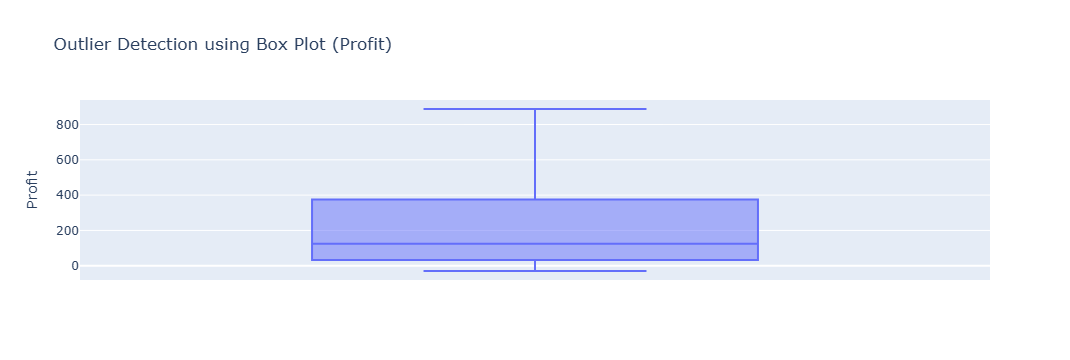

In [60]:
fig = px.box(
    df,
    y="Profit",   
    title="Outlier Detection using Box Plot (Profit)"
)

fig.show()

## 📊 Sales Analysis

💰 Question 1: What are the total sales and profits?

📊 Total Sales: $30,800,622.00
💵 Total Profit: $8,882,585.00
📈 Profit Margin: 28.84%


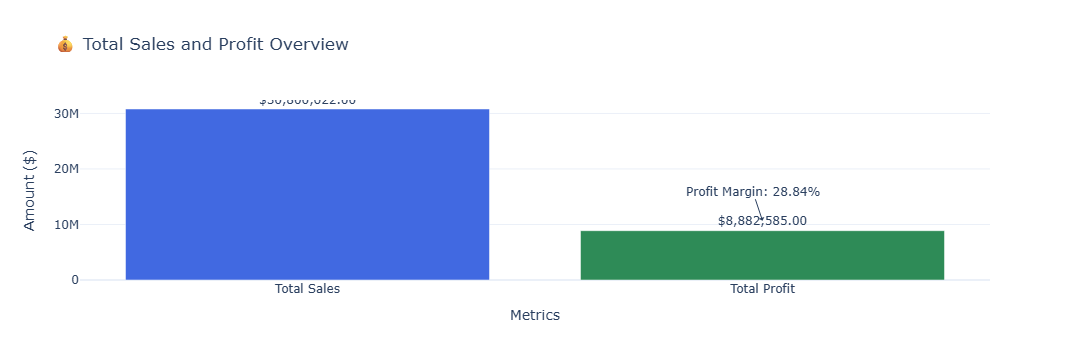

In [61]:
print('💰 Question 1: What are the total sales and profits?\n')

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

profit_margin = (total_profit / total_sales) * 100

print(f'📊 Total Sales: ${total_sales:,.2f}')
print(f'💵 Total Profit: ${total_profit:,.2f}')
print(f'📈 Profit Margin: {profit_margin:.2f}%')
import plotly.graph_objects as go
fig = go.Figure()

fig.add_trace(go.Bar(
    x=['Total Sales', 'Total Profit'],
    y=[total_sales, total_profit],
    text=[f"${total_sales:,.2f}", f"${total_profit:,.2f}"],
    textposition='outside',
    marker_color=['royalblue','seagreen']
))


fig.add_annotation(
    x=1, y=total_profit,
    text=f"Profit Margin: {profit_margin:.2f}%",
    showarrow=True,
    arrowhead=1,
    yshift=10
)

fig.update_layout(
    title="💰 Total Sales and Profit Overview",
    yaxis_title="Amount ($)",
    xaxis_title="Metrics",
    template="plotly_white"
)

fig.show()

🏆 Question 2: Top 10 Best-Selling Products:

                   Product    Sales
0             Road-150 Red  3960846
1      Mountain-200 Silver  3505520
2       Mountain-200 Black  3286440
3         Sport-100 Helmet  2311505
4           Road-250 Black  1861566
5        Road-350-W Yellow  1859193
6        Touring-1000 Blue  1361264
7        Road-550-W Yellow  1168160
8      Touring-1000 Yellow  1144320
9  Long-Sleeve Logo Jersey   873250


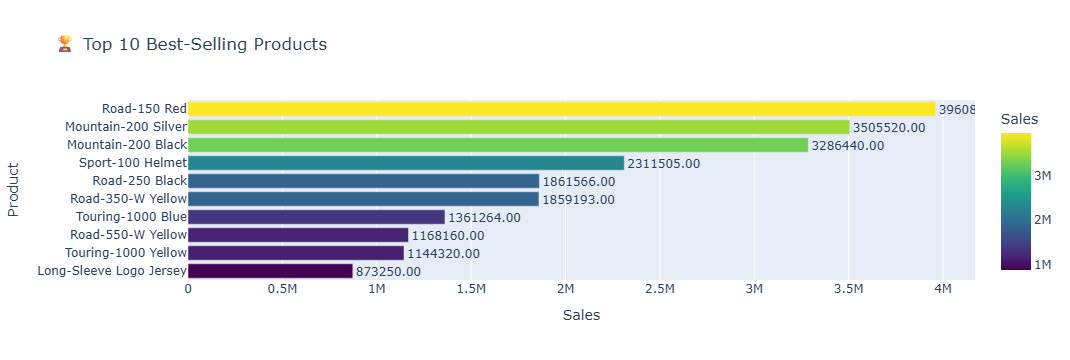

In [62]:
print('🏆 Question 2: Top 10 Best-Selling Products:\n')

top_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()
print(top_products)

fig = px.bar(top_products,
             x='Sales',
             y='Product',
             orientation='h',  # Horizontal layout for better product name readability
             title='🏆 Top 10 Best-Selling Products',
             text='Sales',
             color='Sales',
             color_continuous_scale='Viridis')

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(yaxis={'categoryorder':'total ascending'})  # Sort from highest to lowest sales
fig.show()

📋 Question 3: Top Category by Sales:

  Product_Category     Sales
1            Bikes  23023648
0      Accessories   5268307
2         Clothing   2508667


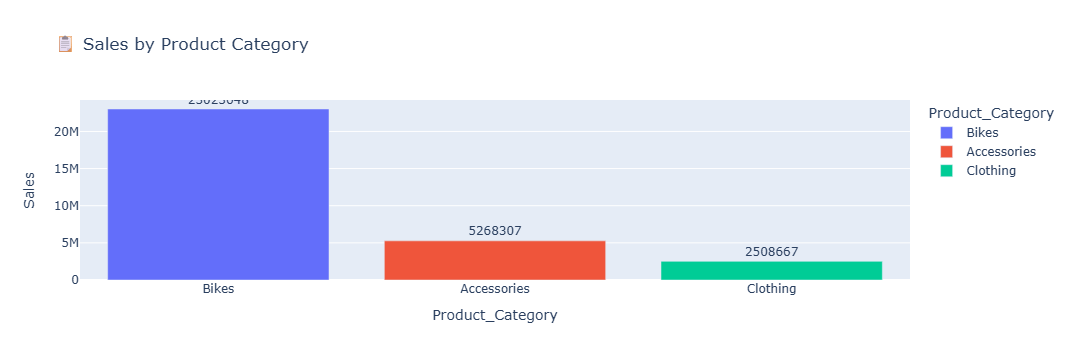

In [63]:
print('📋 Question 3: Top Category by Sales:\n')

sales_by_category_all = df.groupby('Product_Category')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
print(sales_by_category_all)

fig = px.bar(sales_by_category_all,
             x='Product_Category',
             y='Sales',
             title='📋 Sales by Product Category',
             text='Sales',
             color='Product_Category')

fig.update_traces(texttemplate='%{text}', textposition='outside')
fig.show()

In [64]:
print('📋 Question 4: Top 10 Sub-Categories by Sales:\n')

sales_by_subcategory = df.groupby('Sub_Category')['Sales'].sum().sort_values(ascending=False).head(10)
print(sales_by_subcategory)

📋 Question 4: Top 10 Sub-Categories by Sales:

Sub_Category
Road Bikes           11797019
Mountain Bikes        7914768
Touring Bikes         3311861
Helmets               2311505
Tires and Tubes       1647674
Jerseys               1504510
Bottles and Cages      460998
Fenders                275044
Hydration Packs        259930
Vests                  259200
Name: Sales, dtype: int64


In [65]:
print('📋 Question 5: What are the products that cause loss:\n')
losses['Product'].unique()

📋 Question 5: What are the products that cause loss:



array(['AWC Logo Cap', 'Short-Sleeve Classic Jersey'], dtype=object)

## 👥 Customer Analysis

In [66]:
print('📋 Question 1: What is the average age of the customers:\n')
average_age = df['Customer_Age'].mean()
print("Average Customer Age:", average_age)

📋 Question 1: What is the average age of the customers:

Average Customer Age: 35.210114864674175


📋 Question 2: What is the target age group:
Target Age Group: Adults (35-64)
              Age_Group  Count
0        Adults (35-64)  16199
1  Young Adults (25-34)  13587
2           Youth (<25)   5373
3         Seniors (64+)    274


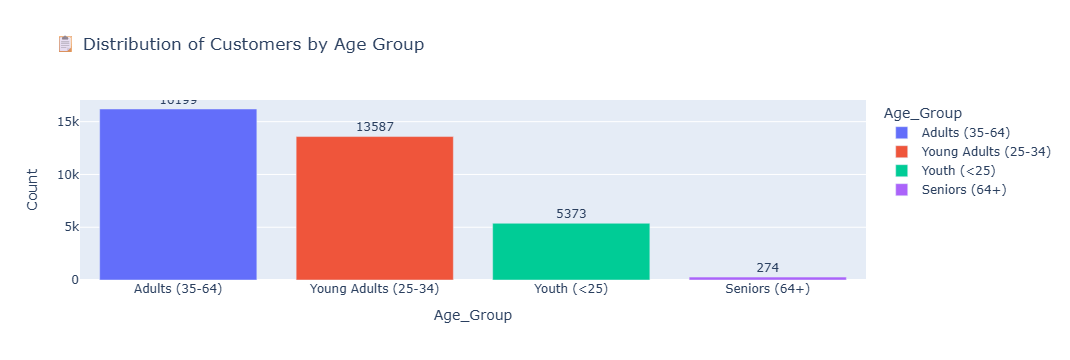

In [67]:
print("📋 Question 2: What is the target age group:")

age_group_counts = df['Age_Group'].value_counts().reset_index()
age_group_counts.columns = ['Age_Group', 'Count']

target_age_group = age_group_counts.iloc[0]['Age_Group']
print("Target Age Group:", target_age_group)
print(age_group_counts)

fig = px.bar(age_group_counts,
             x='Age_Group',
             y='Count',
             title='📋 Distribution of Customers by Age Group',
             text='Count',
             color='Age_Group')

fig.update_traces(texttemplate='%{text}', textposition='outside')
fig.show()

In [68]:
print("📋 Question 3: What is the most common customer gender:")
gender_counts = df['Customer_Gender'].value_counts()
target_gender = gender_counts.idxmax()
print("most common customer gender:", target_gender)
print(gender_counts)

📋 Question 3: What is the most common customer gender:
most common customer gender: M
Customer_Gender
M    17794
F    17639
Name: count, dtype: int64


## 🌍 Geographic Analysis

📋 Question 1: Which country generates the highest total sales? 💰
Country with highest sales: United Kingdom


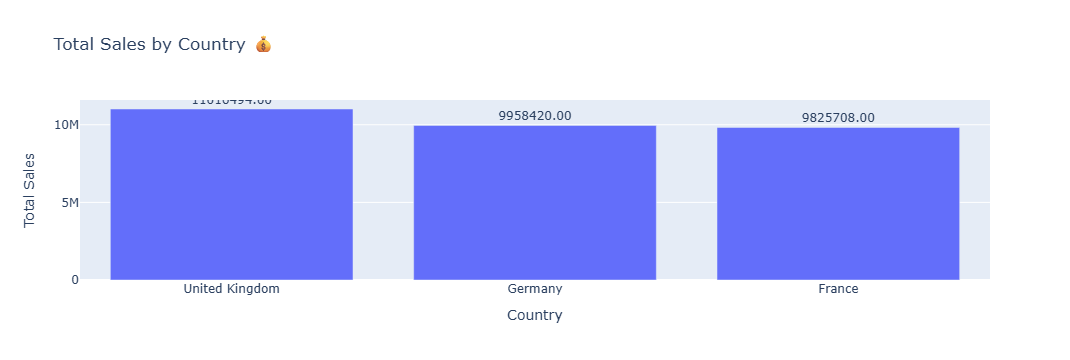

In [69]:
print("📋 Question 1: Which country generates the highest total sales? 💰")

country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False).reset_index()
top_country = country_sales.iloc[0]['Country']
print("Country with highest sales:", top_country)

fig = px.bar(country_sales,
             x='Country',
             y='Sales',
             title='Total Sales by Country 💰',
             labels={'Sales':'Total Sales', 'Country':'Country'},
             text='Sales')
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.show()

📋 Question 2: Which state has the highest sales in each country? 🏆
           Country          State     Sales
9           France  Seine (Paris)   2002882
21         Germany       Saarland   2471294
22  United Kingdom        England  11016494


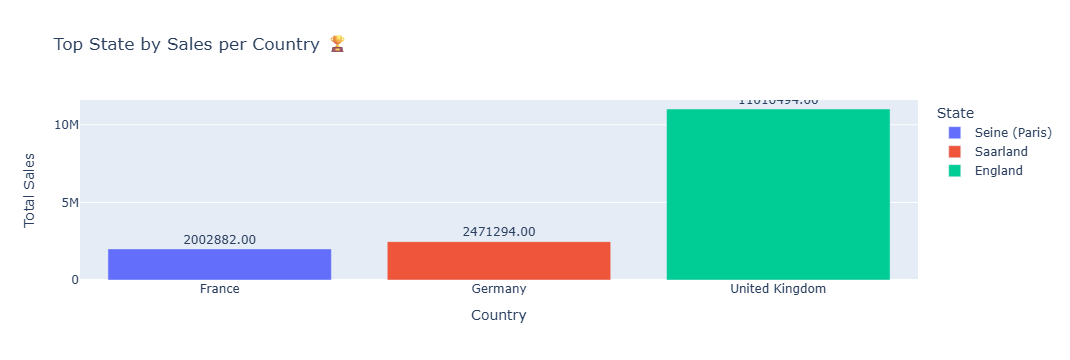

In [70]:
print("📋 Question 2: Which state has the highest sales in each country? 🏆")

state_sales = df.groupby(['Country','State'])['Sales'].sum().reset_index()
top_states = state_sales.loc[state_sales.groupby('Country')['Sales'].idxmax()]
print(top_states)

fig = px.bar(top_states,
             x='Country',
             y='Sales',
             color='State',
             title='Top State by Sales per Country 🏆',
             labels={'Sales':'Total Sales', 'Country':'Country', 'State':'State'},
             text='Sales')
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.show()

## 📅 Time Series Analysis

📅 Question 1: Sales by Year:

   Year    Sales
0  2011  2894136
1  2012  2925276
2  2013  5200554
3  2014  5601767
4  2015  6895533
5  2016  7283356


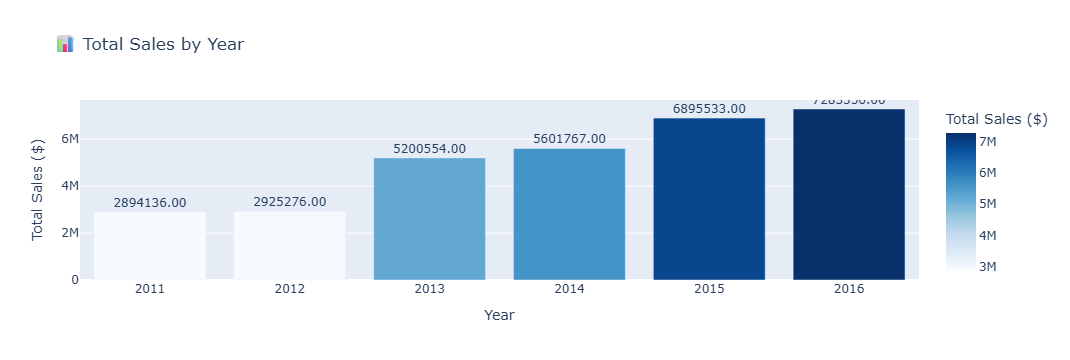

In [71]:
print('📅 Question 1: Sales by Year:\n')

sales_by_year = df.groupby('Year')['Sales'].sum().reset_index()

print(sales_by_year)
fig = px.bar(sales_by_year,
             x='Year',
             y='Sales',
             text='Sales',
             title='📊 Total Sales by Year',
             labels={'Sales':'Total Sales ($)', 'Year':'Year'},
             color='Sales',
             color_continuous_scale='Blues')

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.show()

📆 Question 2: Sales by Month:

        Month    Sales
4     January  2482656
3    February  2596469
7       March  2902941
0       April  2896120
8         May  3198038
6        June  3447349
5        July  1971160
1      August  1879898
11  September  2037953
10    October  1932020
9    November  2001308
2    December  3454710


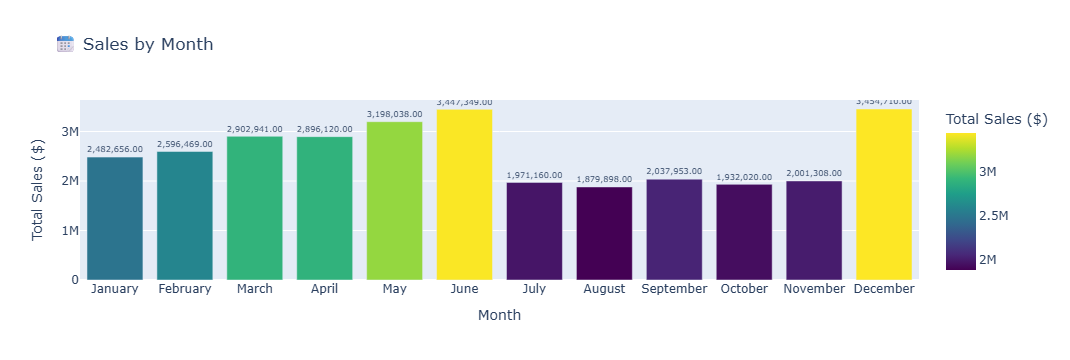

In [72]:
print('📆 Question 2: Sales by Month:\n')

sales_by_month = df.groupby('Month')['Sales'].sum().reset_index()

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
sales_by_month['Month'] = pd.Categorical(sales_by_month['Month'], categories=month_order, ordered=True)
sales_by_month = sales_by_month.sort_values('Month')
print(sales_by_month)

fig = px.bar(sales_by_month,
             x='Month',
             y='Sales',
             text='Sales',
             title='📆 Sales by Month',
             labels={'Sales':'Total Sales ($)', 'Month':'Month'},
             color='Sales',
             color_continuous_scale='Viridis')

fig.update_traces(texttemplate='%{text:,.2f}', textposition='outside')
fig.show()

## 🎁 Discount Analysis

📋 Question 1: What is the distribution of discounts?
discount
0       1012
1       2262
2       1897
3       1551
4       1648
        ... 
2203       1
2254       1
2430       1
2576       6
3435       1
Name: count, Length: 423, dtype: int64


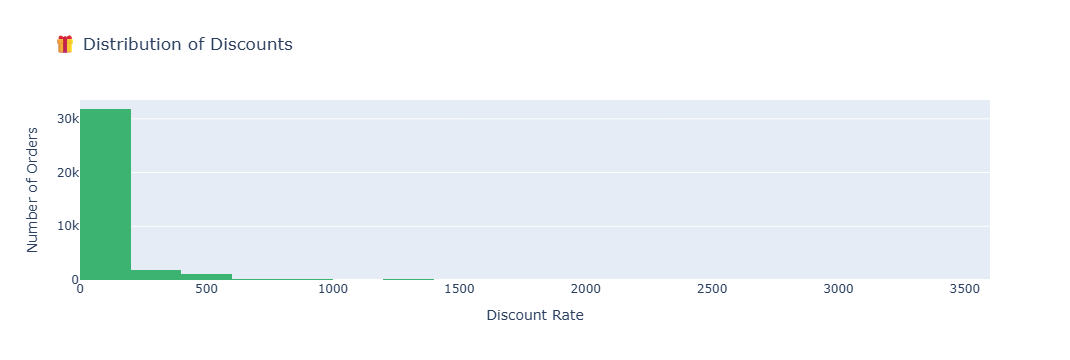

In [73]:
print("📋 Question 1: What is the distribution of discounts?")

discount_distribution = df['discount'].value_counts().sort_index()
print(discount_distribution)

fig = px.histogram(df, x='discount', nbins=20,
                   title="🎁 Distribution of Discounts",
                   labels={'discount':'Discount Rate'},
                   color_discrete_sequence=['mediumseagreen'])
fig.update_layout(yaxis_title="Number of Orders")
fig.show()

📋 Question 2: How do sales vary by discount rate?


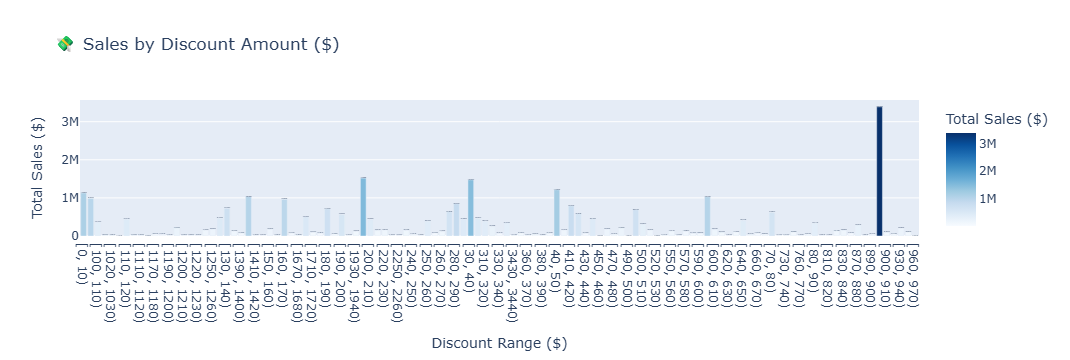

In [74]:
print("📋 Question 2: How do sales vary by discount rate?")

df['Discount_Bin'] = pd.cut(df['discount'], 
                            bins=range(0, int(df['discount'].max()) + 10, 10),
                            right=False)

df['Discount_Bin_str'] = df['Discount_Bin'].astype(str)

sales_by_discount_bin = df.groupby('Discount_Bin_str')['Sales'].sum().reset_index()

fig = px.bar(sales_by_discount_bin,
             x='Discount_Bin_str',
             y='Sales',
             text='Sales',
             title="💸 Sales by Discount Amount ($)",
             labels={'Discount_Bin_str':'Discount Range ($)', 'Sales':'Total Sales ($)'},
             color='Sales',
             color_continuous_scale='Blues')

fig.update_traces(texttemplate='%{text:,.2f}', textposition='outside')
fig.show()

📋 Question 3: How does profit change with discount amount?
    Discount_Bin_str  Profit
0            [0, 10)  578869
1           [10, 20)  458907
2         [100, 110)  124399
3       [1000, 1010)    1776
4       [1020, 1030)    2394
..               ...     ...
112       [900, 910)   11544
113       [910, 920)    9768
114       [930, 940)   25752
115       [950, 960)   12432
116       [960, 970)     888

[117 rows x 2 columns]


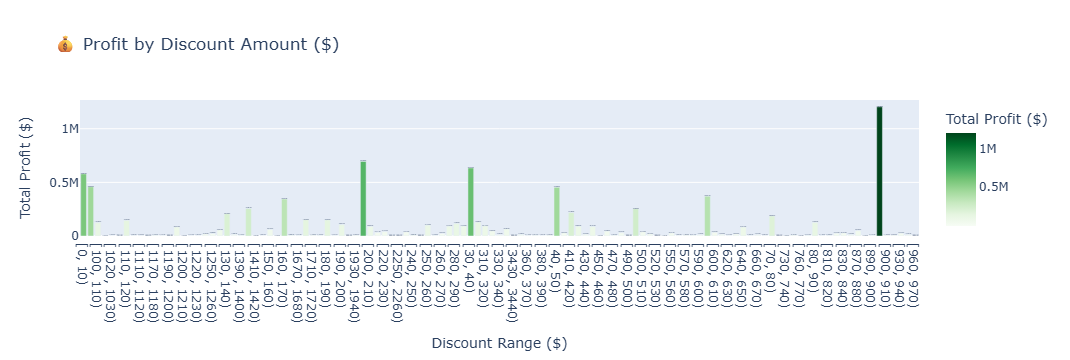

In [75]:
profit_by_discount_bin = df.groupby('Discount_Bin_str')['Profit'].sum().reset_index()

print("📋 Question 3: How does profit change with discount amount?")
print(profit_by_discount_bin)

fig = px.bar(profit_by_discount_bin,
             x='Discount_Bin_str',
             y='Profit',
             text='Profit',
             title="💰 Profit by Discount Amount ($)",
             labels={'Discount_Bin_str':'Discount Range ($)', 'Profit':'Total Profit ($)'},
             color='Profit',
             color_continuous_scale='Greens')

fig.update_traces(texttemplate='%{text:,.2f}', textposition='outside')
fig.show()

---
## ✅ Key Findings & Recommendations

### 📌 Key Findings

1. **Bikes dominate revenue** — the Bikes category generates the highest total sales value, while Accessories lead in order volume.
2. **United Kingdom is the top European market** — it outperforms Germany and France in total sales across all years analysed.
3. **Adults (35–64) are the core customer segment** — this age group accounts for the largest share of orders and sales.
4. **~97% of transactions include a discount** — Unit Price is a list price, not the actual transaction price; effective pricing strategy needs review.
5. **Two products are loss-making** — *AWC Logo Cap* and *Short-Sleeve Classic Jersey* generate negative profit due to near-zero margins.
6. **Sales show clear seasonal patterns** — certain months significantly outperform others, creating inventory and marketing planning opportunities.

### 💡 Recommendations

1. **Review pricing on loss-making products** — raise unit prices or discontinue *AWC Logo Cap* and *Short-Sleeve Classic Jersey* if margin improvement is not feasible.
2. **Capitalise on peak months** — align inventory build-up and marketing spend with the high-demand months identified in the time series analysis.
3. **Audit the discount strategy** — with discounts applied to nearly all transactions, consider targeted discounting by segment or region to protect margins without sacrificing volume.